# Posterior Collapse in a Perturb-seq Virtual-Cell VAE

## Real-World Scenario: A Perturbation-Prediction Model That Predicts "No Effect"

**From PML-2 Chapter 21.4** · *roadmap: Track B — perturbation modeling / virtual cell (Topic 8, the MVP)*

The active founder vertical is the **virtual cell**: a model that predicts *what happens to a cell when we knock out gene X* (Perturb-seq — Norman 2019, Replogle 2022). The workhorse models in this space — **CPA**, **scGen**, **scVI/scLAMBDA** — are all VAEs: an encoder maps a cell's expression profile $\mathbf{x}$ to a latent $\mathbf{z}$ that is meant to carry the **perturbation-induced cell-state shift**, and a decoder reconstructs expression from it.

Here is the trap §21.4 warns about, in the language of this vertical:

> *If the decoder $p_{\boldsymbol\theta}(\mathbf{x}\mid\mathbf{z})$ is sufficiently powerful, then the VAE does not need to use the latent code $\mathbf{z}$ for anything. This is called **posterior collapse** or **variational overpruning**.*

A perturbation effect is **small** relative to the cell-to-cell variation of a control population. An expressive decoder can model the marginal distribution of expression — including the gene–gene correlations a perturbation induces — *without* reading $\mathbf{z}$. The KL term then happily drives $q_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x}) \to p(\mathbf{z})$. The result is a model whose latent **knows nothing about which gene was perturbed** — it effectively predicts the control distribution for every condition.

This is not a toy worry. The 2025 result that a **PCA-linear baseline matches deep perturbation models** (Ahlmann-Eltze et al.) is in part a story about expressive VAEs that *collapse the perturbation signal* and fall back to "predict the mean cell." Avoiding posterior collapse is therefore a load-bearing skill for the Track-B MVP.

In this notebook we:
1. **Reproduce collapse** on Perturb-seq-style data with a vanilla ELBO + a powerful autoregressive decoder — the latent learns nothing about the perturbation.
2. **Fix it** with **KL annealing** (§21.4.1), **cyclical annealing**, and **free bits** (§21.4.3).
3. **Measure** it the way a perturbation-modeling team would: rate, active units, a perturbation-identity probe, and a "does the decoder use $\mathbf{z}$?" test.


In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

device = torch.device('cpu')   # tiny model; CPU is fine
print('torch', torch.__version__)

torch 2.4.1


## Key Formulas from PML-2 §21.4

### The ELBO and the rate (§21.4 intro, Eq. 21.41 specialised to one modality)
$$\mathcal{L}(\boldsymbol\theta,\boldsymbol\phi\mid\mathbf{x}) = \underbrace{\mathbb{E}_{q_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x})}\!\left[\log p_{\boldsymbol\theta}(\mathbf{x}\mid\mathbf{z})\right]}_{-\,\text{distortion}} \; - \; \underbrace{D_{\mathrm{KL}}\!\left(q_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x})\,\|\,p(\mathbf{z})\right)}_{\text{rate } \mathcal{L}_R}$$

**Posterior collapse**: the degenerate optimum where $q_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x}) = p(\mathbf{z})$ for every cell, so $\mathcal{L}_R = 0$ and the decoder reconstructs from a latent it never reads. A powerful decoder makes this attractive — for a virtual-cell model it means the perturbation signal is discarded.

### Fix 1 — KL annealing (§21.4.1)
Scale the rate by a weight $\beta_t$ that ramps **up** $0 \to 1$ (a plain autoencoder → the true ELBO):
$$\mathcal{L}_{\beta_t} = \mathbb{E}_{q}\!\left[\log p_{\boldsymbol\theta}(\mathbf{x}\mid\mathbf{z})\right] - \beta_t\, D_{\mathrm{KL}}\!\left(q_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x})\,\|\,p(\mathbf{z})\right), \qquad \beta_t: 0 \to 1.$$
**Cyclical annealing** repeats the ramp, warm-starting each cycle from the latent learned before.

### Fix 2 — Free bits (§21.4.3, Eqs. 21.58–21.59)
Replace the per-dimension KL with a hinge that stops charging dimensions already below a target rate $\lambda$:
$$\mathcal{L}_R' = \sum_i \max\!\Big(\lambda,\; D_{\mathrm{KL}}\big(q_{\boldsymbol\phi}(z_i\mid\mathbf{x})\,\|\,p(z_i)\big)\Big).$$

The book lists further remedies we revisit at the end: **lower-bounding the rate** (§21.4.2, $\delta$-VAE / vMF posteriors), **skip-VAE** (§21.4.4), **aggressive inference** (§21.4.5), and **InfoVAE** (§21.4.6).


## Step 1: Simulate a Perturb-seq Screen

We synthesise $N = 3500$ cells over $G = 40$ genes. There are **7 conditions**: an unperturbed **control** plus **6 genetic knockouts**. The generative recipe mirrors the dominant sources of variance in a real screen:

- **Shared continuous cell state** $s$ (e.g. cell size / library complexity / cycle phase) loads onto all genes — the *large-variance* axis that dominates a control population.
- **A perturbation program**: each knockout up- or down-regulates a distinct **module of ~6 genes** by a moderate effect — the *small-variance* signal we actually care about.
- **Gene-level noise.**

So each cell is `baseline(cell-state) + perturbation program + noise`. The perturbation is a modest, correlated shift sitting on top of dominant cell-state variation — exactly the regime where an expressive decoder is tempted to model the gene–gene correlations directly and **collapse the perturbation latent**.


In [2]:
G = 40            # genes
N = 3500          # cells
N_PERT = 6        # genetic knockouts (condition 0 = control)
N_COND = N_PERT + 1
MODULE = 6        # genes affected per knockout
EFFECT = 1.6      # perturbation effect size (in expression std units)

rng = np.random.default_rng(0)

# Baseline expression + a shared continuous cell-state factor loading onto all genes.
mu0    = rng.normal(0.0, 1.0, size=G)
load_s = rng.normal(0.0, 1.0, size=G)        # how strongly cell-state drives each gene

# Each knockout perturbs a contiguous module of MODULE genes with mixed up/down shifts.
programs = np.zeros((N_COND, G))
for p in range(1, N_COND):
    genes = np.arange((p - 1) * MODULE, (p - 1) * MODULE + MODULE) % G
    signs = rng.choice([-1.0, 1.0], size=MODULE)
    programs[p, genes] = EFFECT * signs

cond = rng.integers(0, N_COND, size=N)        # condition label per cell
s    = rng.normal(0.0, 1.0, size=N)           # latent cell-state per cell

X = (mu0[None, :]
     + s[:, None] * load_s[None, :]           # dominant cell-state variation
     + programs[cond]                          # the perturbation signal we care about
     + rng.normal(0.0, 0.5, size=(N, G)))      # gene noise
X = (X - X.mean(0)) / X.std(0)                 # standardise per gene
X = X.astype(np.float32)

print('expression matrix:', X.shape, '| conditions:', np.bincount(cond))
print('per-gene std after standardising ~', round(float(X.std(0).mean()), 3))

expression matrix: (3500, 40) | conditions: [501 475 490 495 511 504 524]
per-gene std after standardising ~ 1.0


A quick look at the **mean expression per condition** (a "pseudo-bulk" view). The control row is flat; each knockout lights up its own module of genes. A supervised classifier or a PCA-linear baseline separates these easily — the question is whether the **VAE's latent** will bother to encode them, or collapse them away.


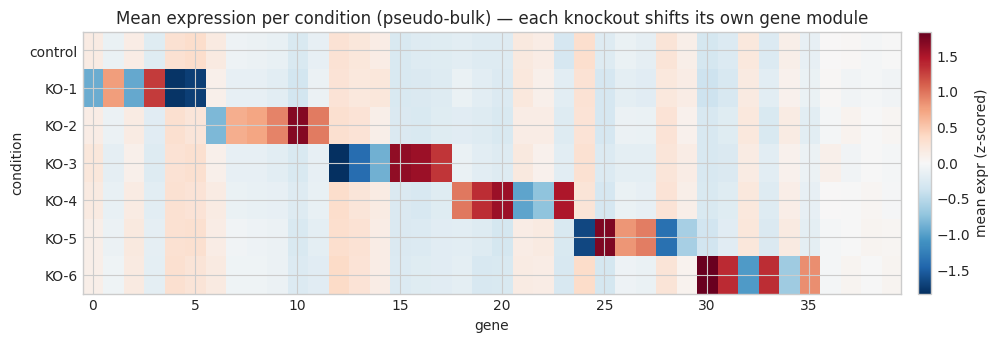

In [3]:
cond_means = np.stack([X[cond == c].mean(0) for c in range(N_COND)])  # (7, G)
fig, ax = plt.subplots(figsize=(11, 3.4))
vmax = np.abs(cond_means).max()
im = ax.imshow(cond_means, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_yticks(range(N_COND))
ax.set_yticklabels(['control'] + [f'KO-{p}' for p in range(1, N_COND)])
ax.set_xlabel('gene'); ax.set_ylabel('condition')
ax.set_title('Mean expression per condition (pseudo-bulk) — each knockout shifts its own gene module')
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label='mean expr (z-scored)')
plt.show()

## Step 2: A VAE with a Powerful (Autoregressive) Decoder

- **Encoder** $q_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x})$: an MLP over the $G$-gene profile → a **diagonal Gaussian** with $K = 10$ latent dimensions.
- **Decoder** $p_{\boldsymbol\theta}(\mathbf{x}\mid\mathbf{z})$: an **autoregressive GRU over genes**. Walking the (fixed) gene order, it predicts each gene's expression $x_g$ as a Gaussian whose mean/variance depend on the previously decoded genes $x_{<g}$ — with $\mathbf{z}$ injected only as the GRU's **initial hidden state**. This is the single-cell analogue of the autoregressive decoders (PixelCNN/RNN) the book names in §21.4 as the cause of collapse: the $x_{<g} \to x_g$ path can reproduce the gene–gene correlations a perturbation induces, so the latent is easy to ignore.

The weak coupling (latent enters only through the initial hidden state) is deliberate — it is the regime where the KL term most easily wins and pushes $q \to p$.


In [4]:
K = 10         # latent dimension
H_ENC = 128    # encoder MLP hidden
H_DEC = 128    # decoder GRU hidden (deliberately powerful)

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(G, H_ENC), nn.ReLU(),
            nn.Linear(H_ENC, H_ENC), nn.ReLU(),
        )
        self.head_mu        = nn.Linear(H_ENC, K)
        self.head_log_sigma = nn.Linear(H_ENC, K)

    def forward(self, x):
        h = self.body(x)
        return self.head_mu(h), self.head_log_sigma(h)

class ARDecoder(nn.Module):
    # Autoregressive over genes: x_g ~ N(mu_g, sigma_g^2) given x_{<g} and z.
    def __init__(self):
        super().__init__()
        self.in_proj = nn.Linear(1, 32)              # embed the previous gene's scalar value
        self.z_to_h  = nn.Linear(K, H_DEC)
        self.gru = nn.GRU(32, H_DEC, batch_first=True)
        self.out = nn.Linear(H_DEC, 2)               # (mean, log-var) per gene
        self.start = nn.Parameter(torch.zeros(1, 1)) # learned value fed before gene 0

    def forward(self, z, x):                          # teacher forcing
        B = x.size(0)
        start = self.start.expand(B, 1)
        inp = torch.cat([start, x[:, :-1]], dim=1).unsqueeze(-1)   # (B, G, 1), shifted right
        h0 = torch.tanh(self.z_to_h(z)).unsqueeze(0)               # (1, B, H_DEC)
        out, _ = self.gru(self.in_proj(inp), h0)
        params = self.out(out)                                     # (B, G, 2)
        mean, log_var = params[..., 0], params[..., 1].clamp(-6, 6)
        return mean, log_var

def reparam(mu, log_sigma):
    return mu + torch.randn_like(mu) * log_sigma.exp()

def gaussian_nll(x, mean, log_var):
    # negative log-likelihood of a diagonal Gaussian, summed over genes, mean over cells
    nll = 0.5 * (log_var + (x - mean) ** 2 / log_var.exp() + np.log(2 * np.pi))
    return nll.sum(1).mean()

print('encoder params:', sum(p.numel() for p in Encoder().parameters()))
print('decoder params:', sum(p.numel() for p in ARDecoder().parameters()))

encoder params: 24340
decoder params: 63939


## Step 3: One Loss, Two Rate Controls

A single ELBO routine, with two independent knobs that match the book:

- **`beta`** — the KL weight $\beta_t$ for **annealing** (§21.4.1).
- **`free_bits`** — the per-dimension floor $\lambda$ for **free bits** (§21.4.3).

The per-dimension KL of a diagonal Gaussian against $\mathcal{N}(0,1)$ is $\tfrac12(\mu_i^2 + \sigma_i^2 - 1 - 2\log\sigma_i)$.


In [5]:
def elbo_terms(enc, dec, x, beta=1.0, free_bits=0.0):
    mu, log_sigma = enc(x)
    z = reparam(mu, log_sigma)
    mean, log_var = dec(z, x)
    recon = gaussian_nll(x, mean, log_var)                     # distortion (nats / cell)
    kl_dim = 0.5 * (mu.pow(2) + (2 * log_sigma).exp() - 1.0 - 2 * log_sigma)
    kl_dim = kl_dim.mean(0)                                    # per-dim KL, averaged over batch
    kl_true = kl_dim.sum()                                     # the real rate (for reporting)
    kl_charged = torch.clamp(kl_dim, min=free_bits).sum() if free_bits > 0 else kl_true
    loss = recon + beta * kl_charged
    return loss, recon.detach(), kl_true.detach(), kl_dim.detach()

X_t = torch.tensor(X, device=device)
cond_t = torch.tensor(cond, device=device)
print('ready:', X_t.shape)

ready: torch.Size([3500, 40])


## Step 4: Train Four Models — Identical Architecture, Different Rate Treatment

| model | rate treatment | section |
|---|---|---|
| **vanilla** | $\beta = 1$ throughout | baseline ELBO |
| **linear anneal** | $\beta_t$ ramps $0 \to 1$ over the first 60% of training | §21.4.1 |
| **cyclical anneal** | $\beta_t$ saw-tooths $0 \to 1$ four times | §21.4.1 |
| **free bits** | $\beta = 1$, $\lambda = 0.5$ nats/dim | §21.4.3 |


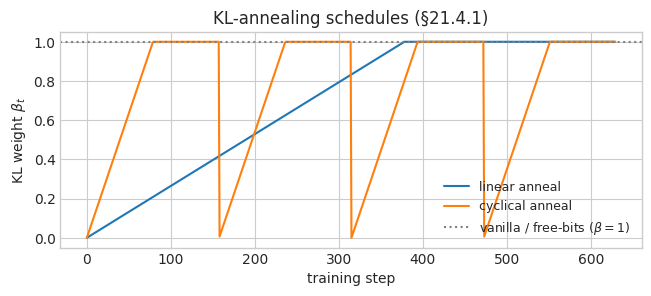

In [6]:
EPOCHS = 45
BATCH = 256
steps_per_epoch = int(np.ceil(N / BATCH))
TOTAL_STEPS = EPOCHS * steps_per_epoch

def schedule_vanilla(step):    return 1.0
def schedule_free_bits(step):  return 1.0

def schedule_linear(step):
    warm = 0.6 * TOTAL_STEPS
    return min(1.0, step / warm)

def schedule_cyclical(step, n_cycles=4):
    period = TOTAL_STEPS / n_cycles
    frac = (step % period) / period
    return min(1.0, frac / 0.5)

steps = np.arange(TOTAL_STEPS)
fig, ax = plt.subplots(figsize=(7.5, 2.8))
ax.plot(steps, [schedule_linear(s)   for s in steps], label='linear anneal')
ax.plot(steps, [schedule_cyclical(s) for s in steps], label='cyclical anneal')
ax.axhline(1.0, color='gray', ls=':', label=r'vanilla / free-bits ($\beta=1$)')
ax.set_xlabel('training step'); ax.set_ylabel(r'KL weight $\beta_t$')
ax.set_title(r'KL-annealing schedules (§21.4.1)'); ax.legend(fontsize=9)
plt.show()

In [7]:
def train(beta_fn, free_bits=0.0, seed=0):
    torch.manual_seed(seed)
    enc, dec = Encoder().to(device), ARDecoder().to(device)
    opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=2e-3)
    hist = {'recon': [], 'kl': []}
    step = 0
    for ep in range(EPOCHS):
        perm = torch.randperm(N)
        r_sum = k_sum = 0.0
        for start in range(0, N, BATCH):
            idx = perm[start:start + BATCH]
            x = X_t[idx]
            beta = beta_fn(step)
            opt.zero_grad()
            loss, recon, kl, _ = elbo_terms(enc, dec, x, beta=beta, free_bits=free_bits)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(list(enc.parameters()) + list(dec.parameters()), 5.0)
            opt.step()
            r_sum += recon.item(); k_sum += kl.item(); step += 1
        hist['recon'].append(r_sum / steps_per_epoch)
        hist['kl'].append(k_sum / steps_per_epoch)
    return {'enc': enc.eval(), 'dec': dec.eval(), 'hist': hist}

configs = {
    'vanilla':            dict(beta_fn=schedule_vanilla,   free_bits=0.0),
    'linear anneal':      dict(beta_fn=schedule_linear,    free_bits=0.0),
    'cyclical anneal':    dict(beta_fn=schedule_cyclical,  free_bits=0.0),
    'free bits (λ=0.5)':  dict(beta_fn=schedule_free_bits, free_bits=0.5),
}

models = {}
for name, cfg in configs.items():
    print(f'training: {name} ...')
    models[name] = train(**cfg)
print('done.')

training: vanilla ...


training: linear anneal ...


training: cyclical anneal ...


training: free bits (λ=0.5) ...


done.


## Step 5: The Rate Over Training — Watching the Collapse

The rate $\mathcal{L}_R = D_{\mathrm{KL}}(q\,\|\,p)$ decaying toward **zero nats** is posterior collapse: the latent stores no information about the cell. We expect **vanilla** to sink — the autoregressive decoder reproduces the gene–gene structure on its own — while the annealed and free-bits models keep a healthy rate.


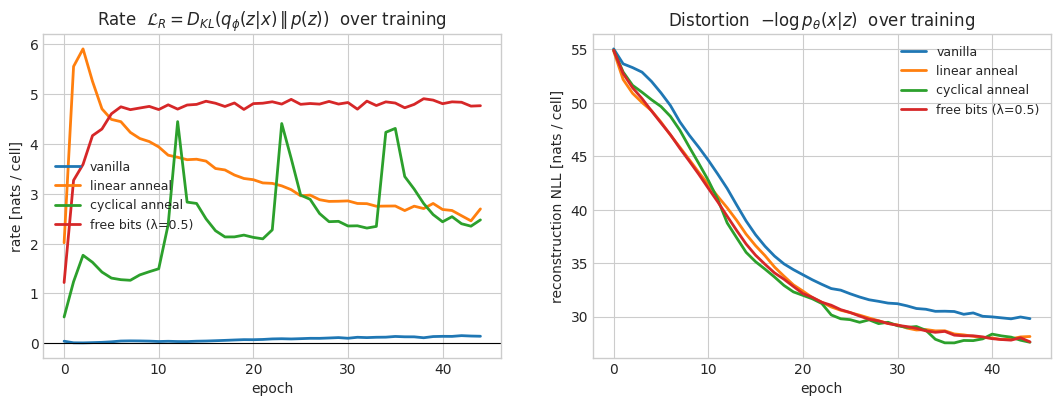

final rate (nats):
  vanilla               KL =   0.142   recon NLL =   29.80
  linear anneal         KL =   2.698   recon NLL =   28.13
  cyclical anneal       KL =   2.478   recon NLL =   27.59
  free bits (λ=0.5)     KL =   4.770   recon NLL =   27.63


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
for name, m in models.items():
    ax1.plot(m['hist']['kl'], label=name, lw=2)
    ax2.plot(m['hist']['recon'], label=name, lw=2)
ax1.set_title(r'Rate  $\mathcal{L}_R = D_{KL}(q_\phi(z|x)\,\|\,p(z))$  over training')
ax1.set_xlabel('epoch'); ax1.set_ylabel('rate [nats / cell]')
ax1.axhline(0, color='k', lw=0.8); ax1.legend(fontsize=9)
ax2.set_title(r'Distortion  $-\log p_\theta(x|z)$  over training')
ax2.set_xlabel('epoch'); ax2.set_ylabel('reconstruction NLL [nats / cell]')
ax2.legend(fontsize=9)
plt.show()

print('final rate (nats):')
for name, m in models.items():
    print(f'  {name:20s}  KL = {m["hist"]["kl"][-1]:7.3f}   recon NLL = {m["hist"]["recon"][-1]:7.2f}')

## Step 6: Active Units — How Many Latent Dimensions Survive?

A dimension is **active** if its dataset-averaged KL is meaningfully above zero. Collapse shows up as a bar chart flat at zero. The fixes should keep a handful of dimensions alive — enough to encode the 6 perturbation programs.


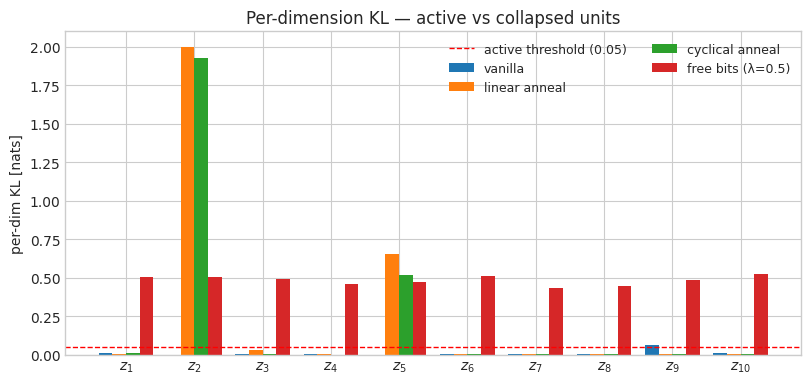

active units (per-dim KL > 0.05):
  vanilla               1 / 10
  linear anneal         2 / 10
  cyclical anneal       2 / 10
  free bits (λ=0.5)     10 / 10


In [9]:
@torch.no_grad()
def per_dim_kl(enc):
    mu, log_sigma = enc(X_t)
    kl = 0.5 * (mu.pow(2) + (2 * log_sigma).exp() - 1.0 - 2 * log_sigma)
    return kl.mean(0).cpu().numpy()

ACTIVE_THRESH = 0.05
fig, ax = plt.subplots(figsize=(9.5, 4.2))
width = 0.2
xp = np.arange(K)
for i, (name, m) in enumerate(models.items()):
    ax.bar(xp + (i - 1.5) * width, per_dim_kl(m['enc']), width=width, label=name)
ax.axhline(ACTIVE_THRESH, color='red', ls='--', lw=1, label=f'active threshold ({ACTIVE_THRESH})')
ax.set_xticks(xp); ax.set_xticklabels([rf'$z_{{{k+1}}}$' for k in range(K)])
ax.set_ylabel('per-dim KL [nats]'); ax.set_title('Per-dimension KL — active vs collapsed units')
ax.legend(fontsize=9, ncol=2)
plt.show()

print('active units (per-dim KL > %.2f):' % ACTIVE_THRESH)
for name, m in models.items():
    print(f'  {name:20s}  {int((per_dim_kl(m["enc"]) > ACTIVE_THRESH).sum())} / {K}')

## Step 7: Does the Latent Encode the Perturbation? (The Test That Matters)

For a virtual-cell model the whole point is that $\mathbf{z}$ should tell us **which gene was knocked out**. We train a **logistic-regression probe** to predict the condition label (7 classes) from the posterior mean $\boldsymbol\mu_{\boldsymbol\phi}(\mathbf{x})$, on a held-out split.

- **Collapsed** latent → accuracy near chance ($1/7 \approx 0.14$): the model has thrown the perturbation signal away — *it predicts the control distribution for everything*.
- **Healthy** latent → high accuracy: knockouts are linearly separable in latent space.


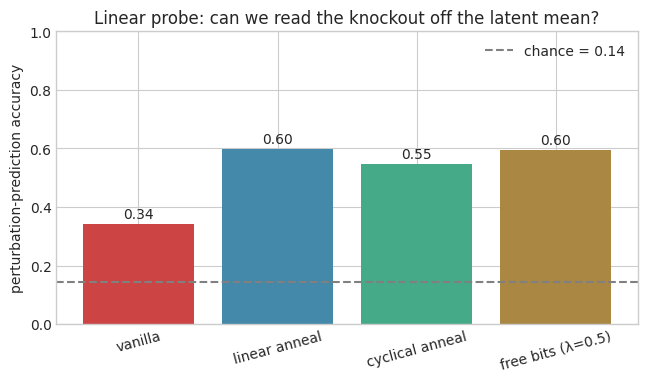

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

@torch.no_grad()
def posterior_means(enc):
    mu, _ = enc(X_t)
    return mu.cpu().numpy()

probe_acc = {}
for name, m in models.items():
    Z = posterior_means(m['enc'])
    Ztr, Zte, ytr, yte = train_test_split(Z, cond, test_size=0.3, random_state=0, stratify=cond)
    clf = LogisticRegression(max_iter=3000)
    clf.fit(Ztr, ytr)
    probe_acc[name] = clf.score(Zte, yte)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
names = list(probe_acc.keys())
ax.bar(names, [probe_acc[n] for n in names], color=['#c44', '#48a', '#4a8', '#a84'])
ax.axhline(1 / N_COND, color='gray', ls='--', label=f'chance = {1/N_COND:.2f}')
ax.set_ylabel('perturbation-prediction accuracy'); ax.set_ylim(0, 1)
ax.set_title('Linear probe: can we read the knockout off the latent mean?')
ax.legend()
for i, n in enumerate(names):
    ax.text(i, probe_acc[n] + 0.02, f'{probe_acc[n]:.2f}', ha='center', fontsize=10)
plt.xticks(rotation=15)
plt.show()

We can *see* the same thing geometrically: project each model's posterior means to 2D (PCA) and colour by the true condition. A collapsed model produces one structureless blob (all cells map to ≈ the same $\boldsymbol\mu$); a healthy model separates the knockouts into distinct clusters.


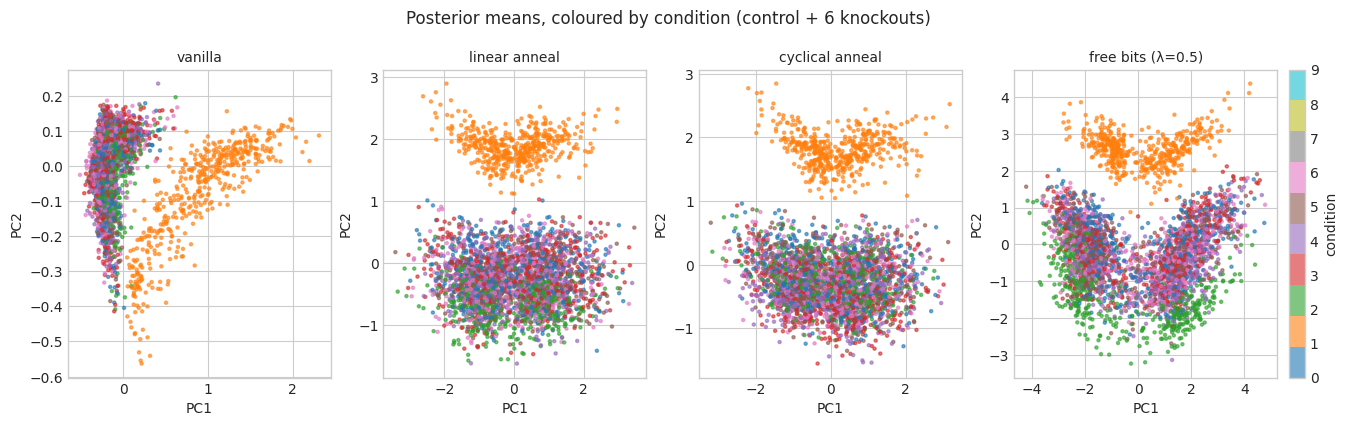

In [11]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, len(models), figsize=(4.0 * len(models), 4.0))
for ax, (name, m) in zip(axes, models.items()):
    Z = posterior_means(m['enc'])
    if np.ptp(Z) < 1e-6:
        Z2 = Z[:, :2]
    else:
        Z2 = PCA(n_components=2).fit_transform(Z)
    sc = ax.scatter(Z2[:, 0], Z2[:, 1], c=cond, cmap='tab10', s=5, alpha=0.6, vmin=0, vmax=9)
    ax.set_title(name, fontsize=10); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
fig.suptitle('Posterior means, coloured by condition (control + 6 knockouts)', y=1.03)
fig.colorbar(sc, ax=axes, fraction=0.015, pad=0.01, label='condition')
plt.show()

## Step 8: Does the Decoder Actually *Read* $\mathbf{z}$?

A decoder-side check. For each cell, encode to $\boldsymbol\mu$ and measure the decoder's **reconstruction NLL** under two conditions:

1. **with the inferred $\mathbf{z} = \boldsymbol\mu$** — the latent for *this* cell;
2. **with a prior sample $\mathbf{z} \sim \mathcal{N}(0,\mathbf{I})$** — an unrelated latent.

If the decoder uses the latent, condition (1) reconstructs better (lower NLL) than (2). Under **posterior collapse** the two are identical — the autoregressive path does all the work and the latent is dead weight.


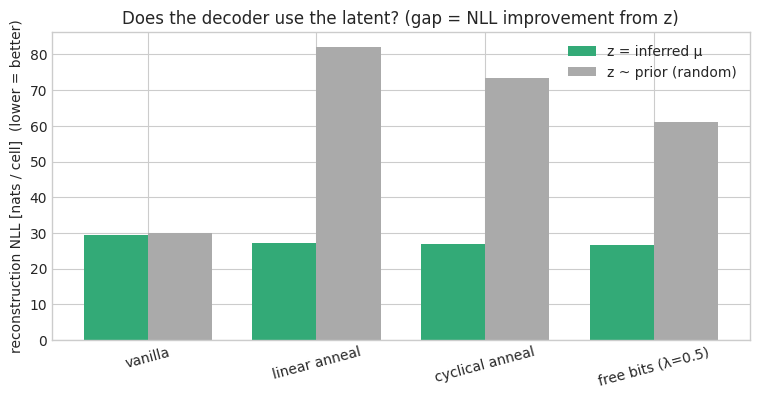

model                   NLL(μ)  NLL(prior)      gap
vanilla                 29.322      29.870    0.548
linear anneal           27.136      82.179   55.043
cyclical anneal         26.838      73.479   46.641
free bits (λ=0.5)       26.577      60.994   34.417


In [12]:
@torch.no_grad()
def recon_nll(dec, z, x):
    mean, log_var = dec(z, x)
    return gaussian_nll(x, mean, log_var).item()

rows = []
for name, m in models.items():
    mu, _ = m['enc'](X_t)
    nll_true  = recon_nll(m['dec'], mu, X_t)
    nll_prior = recon_nll(m['dec'], torch.randn_like(mu), X_t)
    rows.append((name, nll_true, nll_prior, nll_prior - nll_true))   # gap = improvement from z

fig, ax = plt.subplots(figsize=(9, 4.0))
xp = np.arange(len(rows))
w = 0.38
ax.bar(xp - w/2, [r[1] for r in rows], width=w, label='z = inferred μ', color='#3a7')
ax.bar(xp + w/2, [r[2] for r in rows], width=w, label='z ~ prior (random)', color='#aaa')
ax.set_xticks(xp); ax.set_xticklabels([r[0] for r in rows], rotation=15)
ax.set_ylabel('reconstruction NLL [nats / cell]  (lower = better)')
ax.set_title('Does the decoder use the latent? (gap = NLL improvement from z)')
ax.legend()
plt.show()

print(f'{"model":20s} {"NLL(μ)":>9s} {"NLL(prior)":>11s} {"gap":>8s}')
for name, nt, npri, gap in rows:
    print(f'{name:20s} {nt:9.3f} {npri:11.3f} {gap:8.3f}')

The **gap** is the punchline: it is how much the *right* latent improves reconstruction over a random one. A near-zero gap for **vanilla** is posterior collapse made concrete — and for a perturbation model it means the latent carries no actionable information about the knockout. The annealed and free-bits models open a real gap.

## Step 9: The Free-Bits Hinge, Visualised (§21.4.3)

Why do free bits work? Equation 21.59 replaces each dimension's KL with $\max(\lambda,\, \mathrm{KL}_i)$. Below $\lambda$ the penalty is **flat** — zero gradient — so the optimiser feels no pressure to squeeze that dimension to the prior, and the latent is free to *grow into* its first $\lambda$ nats. Above $\lambda$ the usual linear penalty resumes.


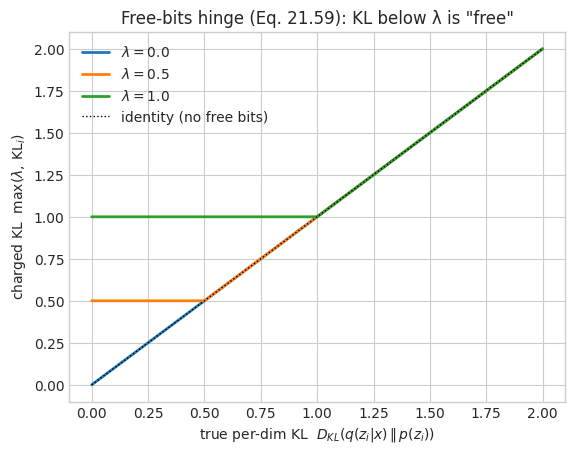

In [13]:
kl_axis = np.linspace(0, 2.0, 400)
for lam in [0.0, 0.5, 1.0]:
    plt.plot(kl_axis, np.maximum(lam, kl_axis), lw=2, label=fr'$\lambda = {lam}$')
plt.plot(kl_axis, kl_axis, 'k:', lw=1, label='identity (no free bits)')
plt.xlabel(r'true per-dim KL  $D_{KL}(q(z_i|x)\,\|\,p(z_i))$')
plt.ylabel(r'charged KL  $\max(\lambda,\, \mathrm{KL}_i)$')
plt.title('Free-bits hinge (Eq. 21.59): KL below λ is "free"')
plt.legend(); plt.show()

## Why This Matters for the Track-B MVP

This notebook is a miniature of the failure mode that makes perturbation modeling hard:

- **A collapsed perturbation-VAE = "predict the control."** When the latent carries no knockout information, the model's best guess for any perturbed cell is the unperturbed mean. That is *exactly* the regime in which a **PCA-linear baseline matches deep models** (Ahlmann-Eltze 2025) — the headline result the MVP's eval harness must be able to detect. A perturbation model that has silently collapsed will look fine on reconstruction loss yet be useless for its actual job.
- **The eval has to measure latent usage, not just ELBO.** Steps 5–8 (rate, active units, perturbation probe, decoder-uses-$\mathbf{z}$ gap) are precisely the diagnostics a benchmark like **PerturBench / PertEval-scFM** operationalises. Low reconstruction loss with a dead latent is the trap.
- **The real models in this vertical face this directly.** **CPA** factorises the latent into a basal cell state plus an additive perturbation embedding (an architectural anti-collapse move close in spirit to skip connections, §21.4.4); **scGen** works in a latent space and adds perturbation vectors; **scVI** ships KL warm-up (annealing) by default. Knowing *why* those design choices exist is the point of §21.4.

### The other fixes in §21.4
- **§21.4.2 — Lower-bounding the rate.** Constrain the posterior so it cannot collapse: a **von Mises–Fisher** posterior with fixed concentration $\kappa$, or the **$\delta$-VAE**'s autoregressive prior, pin the rate at $\geq \delta$.
- **§21.4.4 — Skip connections (skip-VAE).** Route $\mathbf{z}$ into many decoder layers so its gradient signal stays strong (Fig. 21.10). Our single "initial hidden state" injection is the weak-coupling case that collapses most easily — CPA's additive perturbation latent is the opposite design.
- **§21.4.5 — Improved variational inference.** Aggressively optimise the encoder before each decoder step (He et al. 2019) to close the amortization gap.
- **§21.4.6 — Alternative objectives (InfoVAE).** Add a term that forces non-zero mutual information $\mathbb{I}(\mathbf{x};\mathbf{z})$, directly outlawing the collapsed solution (includes MMD/adversarial autoencoders).


## Summary

### What we built
A CPA/scGen-style VAE over a synthetic **Perturb-seq screen** (control + 6 genetic knockouts), with a powerful autoregressive-over-genes decoder, trained four ways that differ *only* in how the rate term is handled — so we could watch posterior collapse discard the perturbation signal and then be cured.

### Key takeaways from PML-2 §21.4
1. **Powerful decoders cause collapse.** The autoregressive decoder models the gene–gene structure on its own, so the vanilla ELBO drives the rate $D_{\mathrm{KL}}(q\,\|\,p) \to 0$ and the latent learns nothing about the knockout (Steps 5–7). This is **posterior collapse / variational overpruning**.
2. **Four diagnostics, one verdict.** Vanishing rate (Step 5), zero active units (Step 6), chance-level perturbation probe (Step 7), and a zero decoder-uses-$\mathbf{z}$ gap (Step 8) all agree — and all flip for the fixed models.
3. **KL annealing (§21.4.1)** and **free bits (§21.4.3)** both revive the latent; free bits keeps the most dimensions active by refusing to charge for the first $\lambda$ nats per dimension (Step 9).
4. **Many roads to the fix:** lower-bounding the rate (§21.4.2), skip-VAE (§21.4.4), aggressive inference (§21.4.5), InfoVAE (§21.4.6).

### The founder-path lesson
A perturbation-VAE that has silently collapsed reports a fine ELBO and predicts *no effect* — indistinguishable from the control mean, and beaten by a linear baseline. Detecting and preventing that is an eval-and-training-discipline problem, which is exactly the whitespace the Track-B MVP is built around.
